In [52]:
# ============================================================
# Event selection only (no plotting, no saving)
# - Load Excel, compute dt_rel vs FC per (station,starttime) event
# - Select events by dt_rel criteria (per scenario)
# - Match Excel events to MiniSEED traces by starttime tolerance
# - Print: per scenario list of selected events (time, station, epicentral distance)
# ============================================================

import numpy as np
import pandas as pd
from obspy import read

# -------------------------
# CONFIG
# -------------------------
xlsx  = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/Shallow_processed_RESULTS.xlsx"
sheet = "best_7_bands_fixed_hold0"

MSEED_PATH = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/notebooks/All_Shallow_Moonquakes.mseed"

FC    = 5.0
BANDS = np.array([3., 4., 5., 6., 7., 8., 9.])

STARTTIME_TOL_S = 2.0

SCENARIOS = [
    dict(LOWER_TOL=0.75, MIN_POST=2, K_NEG=1, K_PRE_POS=1),
]


def load_excel_long(xlsx, sheet, *, FC, BANDS):
    d = pd.read_excel(xlsx, sheet_name=sheet)

    need = ["starttime", "station", "fc_hz", "t0_dt_mean"]
    missing = [c for c in need if c not in d.columns]
    if missing:
        raise KeyError(
            f"Missing columns in sheet '{sheet}': {missing}\n"
            f"Available: {list(d.columns)}"
        )

    d["station"] = d["station"].astype(str)
    d["fc_hz"] = pd.to_numeric(d["fc_hz"], errors="coerce").astype(float)
    d["starttime_dt"] = pd.to_datetime(d["starttime"], errors="coerce", utc=True)
    d["t0_dt_mean_dt"] = pd.to_datetime(d["t0_dt_mean"], errors="coerce", utc=True)

    if "distance" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["distance"], errors="coerce")
    elif "epi_deg" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["epi_deg"], errors="coerce")
    else:
        d["distance_deg"] = np.nan

    d = d[d["fc_hz"].isin(BANDS)].copy()
    d["event"] = d["starttime_dt"].astype(str) + "__" + d["station"]

    ref = (
        d[d["fc_hz"].eq(FC)][["event", "t0_dt_mean_dt"]]
        .rename(columns={"t0_dt_mean_dt": "t0_fc_dt"})
        .groupby("event", as_index=False)["t0_fc_dt"]
        .min()
    )
    d = d.merge(ref, on="event", how="left")
    d["dt_rel"] = (d["t0_dt_mean_dt"] - d["t0_fc_dt"]).dt.total_seconds()

    d = d[d["dt_rel"].notna() & d["starttime_dt"].notna() & d["t0_dt_mean_dt"].notna()].copy()

    return d[[
        "event", "station", "starttime_dt", "fc_hz", "dt_rel",
        "distance_deg", "t0_dt_mean_dt"
    ]].rename(columns={"fc_hz": "band"})


def build_event_band_matrix(df_long, *, BANDS):
    return (
        df_long.pivot_table(index="event", columns="band", values="dt_rel", aggfunc="first")
        .reindex(columns=BANDS)
        .sort_index()
    )


def select_events(*, dt_mat, FC, BANDS, MIN_POST, K_NEG, K_PRE_POS=0, LOWER_TOL=0.0):
    post_bands = [b for b in BANDS if b > FC]
    pre_bands = [b for b in BANDS if b < FC]

    keep = []
    for ev in dt_mat.index:
        dt = dt_mat.loc[ev]

        post_vals = dt[post_bands].dropna()
        if len(post_vals) < MIN_POST:
            keep.append(False)
            continue

        n_post_nonpos = int((post_vals <= LOWER_TOL).sum())
        if n_post_nonpos > K_NEG:
            keep.append(False)
            continue

        pre_vals = dt[pre_bands].dropna()
        n_pre_pos = int((pre_vals > LOWER_TOL).sum())
        if n_pre_pos > K_PRE_POS:
            keep.append(False)
            continue

        keep.append(True)

    return pd.Series(keep, index=dt_mat.index, name="keep")


def match_traces_to_excel_events(st, df_long, tol_s):
    by_sta = {sta: g.copy() for sta, g in df_long.groupby("station")}
    event_to_trace = {}

    for tr in st:
        sta = str(getattr(tr.stats, "station", "")).strip()
        if not sta or sta not in by_sta:
            continue

        tr_t0 = pd.Timestamp(tr.stats.starttime.datetime, tz="UTC")
        g = by_sta[sta]
        dt = (g["starttime_dt"] - tr_t0).dt.total_seconds().abs()

        j = dt.idxmin()
        if not np.isfinite(dt.loc[j]):
            continue

        if dt.loc[j] <= tol_s:
            ev = g.loc[j, "event"]
            if ev in event_to_trace:
                prev_tr, prev_diff = event_to_trace[ev]
                if dt.loc[j] < prev_diff:
                    event_to_trace[ev] = (tr, float(dt.loc[j]))
            else:
                event_to_trace[ev] = (tr, float(dt.loc[j]))

    return {ev: tr for ev, (tr, _) in event_to_trace.items()}


df_long = load_excel_long(xlsx, sheet, FC=FC, BANDS=BANDS)
dt_mat = build_event_band_matrix(df_long, BANDS=BANDS)
t0_mat = (
    df_long.pivot_table(index="event", columns="band", values="t0_dt_mean_dt", aggfunc="first")
    .reindex(columns=BANDS)
    .sort_index()
)

dist_map = (
    df_long[["event", "distance_deg"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["distance_deg"]
    .to_dict()
)

t0best_map = (
    df_long[df_long["band"] == FC][["event", "t0_dt_mean_dt"]]
    .dropna()
    .drop_duplicates(subset=["event"])
    .set_index("event")["t0_dt_mean_dt"]
    .to_dict()
)

st = read(MSEED_PATH)
event_to_trace = match_traces_to_excel_events(st, df_long, tol_s=STARTTIME_TOL_S)
print(f"Matched {len(event_to_trace)} Excel events to MiniSEED traces (tol={STARTTIME_TOL_S}s).")

selected_rows = []
for cfg in SCENARIOS:
    keep_mask = select_events(
        dt_mat=dt_mat,
        FC=FC,
        BANDS=BANDS,
        MIN_POST=int(cfg["MIN_POST"]),
        K_NEG=int(cfg["K_NEG"]),
        K_PRE_POS=int(cfg["K_PRE_POS"]),
        LOWER_TOL=float(cfg["LOWER_TOL"]),
    )

    kept_events = [ev for ev in keep_mask.index[keep_mask].tolist() if ev in event_to_trace]
    print(f"Selected {len(kept_events)} events after dt_rel filtering and MiniSEED matching.")

    for ev in kept_events:
        selected_rows.append({
            "event": ev,
            "time_utc": t0best_map.get(ev, pd.NaT),
            "station": ev.split("__", 1)[-1],
            "epi_deg": dist_map.get(ev, np.nan),
        })

selected_events_df = (
    pd.DataFrame(selected_rows)
    .drop_duplicates(subset=["event"])
    .sort_values(["epi_deg", "time_utc"], na_position="last")
    .reset_index(drop=True)
)

print(selected_events_df.to_string(index=False))


Matched 43 Excel events to MiniSEED traces (tol=2.0s).
Selected 15 events after dt_rel filtering and MiniSEED matching.
                                event                         time_utc station    epi_deg
1976-03-06 10:03:00.015000+00:00__S15 1976-03-06 10:14:28.251000+00:00     S15  34.369254
1971-05-20 17:16:10.013000+00:00__S14 1971-05-20 17:29:00.023000+00:00     S14  46.000000
1976-03-08 14:33:00.011000+00:00__S15 1976-03-08 14:45:13.651000+00:00     S15  47.933383
1975-11-10 07:46:00.004000+00:00__S16 1975-11-10 07:55:39.439000+00:00     S16  48.000000
1976-01-04 11:09:00.035000+00:00__S16 1976-01-04 11:22:14.578000+00:00     S16  55.664065
1976-03-06 10:03:00.009000+00:00__S14 1976-03-06 10:15:48.794000+00:00     S14  56.580047
1975-05-07 06:28:05.013000+00:00__S16 1975-05-07 06:40:33.637000+00:00     S16  64.000000
1972-12-06 22:59:00.008000+00:00__S14 1972-12-06 23:12:43.085000+00:00     S14  70.772241
1972-01-02 22:20:40.002000+00:00__S15 1972-01-02 22:33:11.391000+00:00

In [53]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.signal import butter, sosfiltfilt, hilbert, get_window


def log10_envelope(x):
    x = np.asarray(x, float)
    pos = x[x > 0]
    if pos.size == 0:
        floor = 1e-12
    else:
        floor = min(1e-12, max(1e-300, 0.1 * np.min(pos)))
    return np.log10(np.clip(x, floor, None))


def coda_log10_model(t, log10_A2, q0, alpha, sigma_km, D_km, water_level):
    t = np.asarray(t, float)
    t = np.clip(t, T_EPS_SEC, None)

    A2 = 10 ** log10_A2
    q = 1 - 10 ** (-q0)
    q = np.clip(q, 1e-6, 0.999999)

    sigma_km = max(1e-3, sigma_km)
    S = (D_km / sigma_km) ** 2

    inv_alpha_t = 1 / (alpha * t)
    exponent = -inv_alpha_t * S
    power_term = np.exp(alpha * t * np.log(q))

    e = A2 * power_term * inv_alpha_t * np.exp(exponent)
    e = np.clip(e, water_level, None)
    return np.log10(e)


def band_edges(fc, half_bw, fs):
    fl = max(fc - half_bw, 0.001)
    fu = min(fc + half_bw, 0.99 * fs / 2)
    return fl, fu


def env_and_rms(x, fs, fl, fu, win_s, order):
    sos = butter(order, [fl / (fs / 2), fu / (fs / 2)], btype="bandpass", output="sos")
    bp = sosfiltfilt(sos, x)
    env = np.abs(hilbert(bp))

    N = int(round(win_s * fs)) | 1
    w = get_window("hann", N)
    w = w / w.sum()
    rms = np.sqrt(np.convolve(env**2, w, mode="same"))
    return env, rms


T_EPS_SEC = 1.0
P_LOWER = np.array([-16.0, 0.01, 0.01, 0.1], float)
P_UPPER = np.array([15.0, 10.0, 5.0, 500.0], float)
P0 = np.array([-6.0, 2.0, 1.3, 100.0], float)


def waterlevelcode(
    t,
    amp,
    *,
    D,
    fit_start,
    fit_end,
    noise_window=(0, 300),
    min_noise_n=20,
    min_fit_n=80,
):
    t = np.asarray(t, float)
    amp = np.asarray(amp, float)

    finite = np.isfinite(t) & np.isfinite(amp)
    positive = amp > 0
    env_log = log10_envelope(np.abs(amp))

    n_lo, n_hi = noise_window
    noise_mask = finite & positive & (t >= n_lo) & (t < n_hi)
    if np.sum(noise_mask) < min_noise_n:
        raise RuntimeError("Not enough points in noise window")

    noise_log = np.mean(env_log[noise_mask])
    water_level = 10 ** noise_log

    fit_mask = finite & positive & (t >= fit_start) & (t <= fit_end)
    if np.sum(fit_mask) < min_fit_n:
        raise RuntimeError("Not enough points in fit window")

    t_fit = t[fit_mask] - fit_start
    y_fit = env_log[fit_mask]

    def residuals(p):
        y_model = coda_log10_model(t_fit, p[0], p[1], p[2], p[3], D, water_level)
        return y_model - y_fit

    result = least_squares(
        residuals,
        P0,
        bounds=(P_LOWER, P_UPPER),
        method="trf",
        max_nfev=2000,
    )
    if not result.success:
        raise RuntimeError("Fit did not converge")

    log10_A2, q0, alpha, sigma = result.x
    ssr = float(np.dot(result.fun, result.fun))
    cost = float(result.cost)
    rmse = float(np.sqrt(ssr / result.fun.size))

    return {
        "log10_A2": log10_A2,
        "q0": q0,
        "alpha": alpha,
        "sigma": sigma,
        "water_level": water_level,
        "fit_start": fit_start,
        "fit_end": fit_end,
        "success": result.success,
        "message": result.message,
        "n_resid": int(result.fun.size),
        "ssr": ssr,
        "cost": cost,
        "rmse": rmse,
    }


RESULTS_DIR = os.path.join(os.getcwd(), "results", "LSQ_Fitting")
os.makedirs(RESULTS_DIR, exist_ok=True)
RESULTS_CSV = os.path.join(RESULTS_DIR, "fit_envelopes_improvement_all_events.csv")

half_bw = 0.5
win_s = 5
order = 4
D_km = 1700
noise_window = (-300, 0)
fit_start = -20.0
fit_end = 100.0
MIN_NOISE_N = 20
MIN_FIT_N = 80
PLOT_FIRST_EVENT_ONLY = False

results_all_events = []
failed_fits = []

for event_idx, row in selected_events_df.iterrows():
    ev = row["event"]
    tr = event_to_trace.get(ev)
    if tr is None:
        failed_fits.append({"event": ev, "fc_Hz": np.nan, "reason": "Missing MiniSEED trace"})
        continue

    tr_start_utc = pd.Timestamp(tr.stats.starttime.datetime, tz="UTC")
    fs = float(tr.stats.sampling_rate)
    x = tr.data.astype(float)
    t_raw = np.arange(x.size) / fs

    print(f"Processing event {event_idx + 1}/{len(selected_events_df)}: {ev}")

    for fc_band in BANDS:
        try:
            t0_utc = t0_mat.loc[ev, fc_band]
        except KeyError:
            t0_utc = pd.NaT

        if pd.isna(t0_utc):
            failed_fits.append({"event": ev, "fc_Hz": float(fc_band), "reason": "Missing t0_dt_mean"})
            continue

        t0_utc = pd.Timestamp(t0_utc)
        if t0_utc.tzinfo is None:
            t0_utc = t0_utc.tz_localize("UTC")
        else:
            t0_utc = t0_utc.tz_convert("UTC")

        t0_offset_sec = (t0_utc - tr_start_utc).total_seconds()
        t = t_raw - t0_offset_sec

        fl, fu = band_edges(fc_band, half_bw, fs)
        env_trim, rms = env_and_rms(x, fs, fl, fu, win_s, order)
        if env_trim.size == t.size:
            t_env = t
            amp_for_fit = rms
        else:
            dn = t.size - env_trim.size
            i0 = dn // 2
            t_env = t[i0:i0 + env_trim.size]
            amp_for_fit = rms

        try:
            fit = waterlevelcode(
                t_env,
                amp_for_fit,
                D=D_km,
                fit_start=fit_start,
                fit_end=fit_end,
                noise_window=noise_window,
                min_noise_n=MIN_NOISE_N,
                min_fit_n=MIN_FIT_N,
            )
        except Exception as exc:
            failed_fits.append({"event": ev, "fc_Hz": float(fc_band), "reason": str(exc)})
            continue

        if PLOT_FIRST_EVENT_ONLY and event_idx == 0:
            t_model = np.linspace(fit_start, fit_end, 2000)
            t_rel = t_model - fit_start
            y_model = coda_log10_model(t_rel, fit["log10_A2"], fit["q0"], fit["alpha"], fit["sigma"], D_km, fit["water_level"])
            amp_model = 10 ** y_model
            fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
            axes[0].plot(t_env, amp_for_fit, color="k", lw=1, label="Observed")
            axes[0].plot(t_model, amp_model, lw=2, label="Fit")
            axes[0].axvline(fit_start, ls="--")
            axes[0].axvline(fit_end, ls="--")
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)
            axes[1].semilogy(t_env, amp_for_fit, color="k", lw=1)
            axes[1].semilogy(t_model, amp_model, lw=2)
            axes[1].axvline(fit_start, ls="--")
            axes[1].axvline(fit_end, ls="--")
            axes[1].grid(True, which="both", alpha=0.3)
            plt.suptitle(f"{ev} | {fc_band:.1f} Hz")
            plt.tight_layout()
            plt.show()

        results_all_events.append({
            "event": ev,
            "station": row["station"],
            "epi_deg": row["epi_deg"],
            "event_time_utc": row["time_utc"],
            "fc_Hz": float(fc_band),
            "t0_utc": t0_utc,
            "t0_offset_sec": float(t0_offset_sec),
            "fl_Hz": float(fl),
            "fu_Hz": float(fu),
            **fit,
        })

results_all_events_df = pd.DataFrame(results_all_events).sort_values(["event_time_utc", "fc_Hz"]).reset_index(drop=True)
failed_fits_df = pd.DataFrame(failed_fits)
results_all_events_df.to_csv(RESULTS_CSV, index=False)

print()
print(f"Stored {len(results_all_events_df)} band fits across {results_all_events_df['event'].nunique()} events.")
print(f"Saved results to: {RESULTS_CSV}")
if not failed_fits_df.empty:
    print(f"Skipped {len(failed_fits_df)} event/band fits.")


Processing event 1/15: 1976-03-06 10:03:00.015000+00:00__S15
Processing event 2/15: 1971-05-20 17:16:10.013000+00:00__S14
Processing event 3/15: 1976-03-08 14:33:00.011000+00:00__S15
Processing event 4/15: 1975-11-10 07:46:00.004000+00:00__S16
Processing event 5/15: 1976-01-04 11:09:00.035000+00:00__S16
Processing event 6/15: 1976-03-06 10:03:00.009000+00:00__S14
Processing event 7/15: 1975-05-07 06:28:05.013000+00:00__S16
Processing event 8/15: 1972-12-06 22:59:00.008000+00:00__S14
Processing event 9/15: 1972-01-02 22:20:40.002000+00:00__S15
Processing event 10/15: 1973-06-20 20:15:00.023000+00:00__S15
Processing event 11/15: 1975-01-03 01:32:00.013000+00:00__S15
Processing event 12/15: 1975-01-12 03:04:00.017000+00:00__S14
Processing event 13/15: 1973-03-13 07:47:00.014000+00:00__S14
Processing event 14/15: 1974-07-11 00:37:00.006000+00:00__S14
Processing event 15/15: 1973-03-13 07:47:00.013000+00:00__S15

Stored 96 band fits across 15 events.
Saved results to: /Users/ramonmargarit/I

                                event station    epi_deg  fc_Hz  success  fit_start  fit_end       cost        ssr     rmse  log10_A2       q0    alpha      sigma  water_level
1971-05-20 17:16:10.013000+00:00__S14     S14  46.000000    3.0     True      -20.0    100.0  29.268400  58.536800 0.095937 -7.079374 6.462105 0.720295 183.056812 1.821118e-11
1971-05-20 17:16:10.013000+00:00__S14     S14  46.000000    5.0     True      -20.0    100.0  33.891552  67.783104 0.103236 -6.857535 7.857862 1.516100 120.975995 1.290115e-11
1971-05-20 17:16:10.013000+00:00__S14     S14  46.000000    6.0     True      -20.0    100.0  65.779700 131.559401 0.143824 -6.593550 2.358503 1.527783 117.800028 8.902445e-12
1971-05-20 17:16:10.013000+00:00__S14     S14  46.000000    7.0     True      -20.0    100.0  40.025098  80.050196 0.112190 -6.591203 2.416912 1.493028 114.598810 8.548286e-12
1972-01-02 22:20:40.002000+00:00__S15     S15  73.000000    4.0     True      -20.0    100.0  50.704291 101.408582 0.126

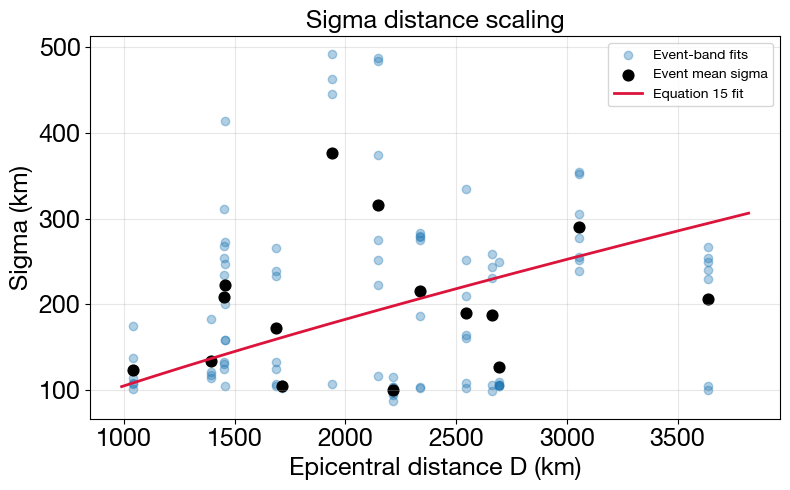


Equation 15 fit per frequency band:
Band 3.0 Hz: sigma0=156.856 km, beta=0.800 (fixed)
                                event station    epi_deg      epi_km  sigma_mean  sigma_pred
1976-03-06 10:03:00.015000+00:00__S15     S15  34.369254 1042.190937  114.167562   93.118440
1971-05-20 17:16:10.013000+00:00__S14     S14  46.000000 1394.874120  183.056812  117.572532
1976-03-08 14:33:00.011000+00:00__S15     S15  47.933383 1453.500759  133.124513  121.509454
1975-11-10 07:46:00.004000+00:00__S16     S16  48.000000 1455.520820  158.400344  121.644533
1976-01-04 11:09:00.035000+00:00__S16     S16  55.664065 1687.920952  106.569929  136.949213
1976-03-06 10:03:00.009000+00:00__S14     S14  56.580047 1715.696605  101.898534  138.749124
1972-12-06 22:59:00.008000+00:00__S14     S14  70.772241 2146.051452  275.318525  165.954855
1973-06-20 20:15:00.023000+00:00__S15     S15  77.000000 2334.897983  275.247428  177.538353
1975-01-03 01:32:00.013000+00:00__S15     S15  83.980853 2546.580825  102.0

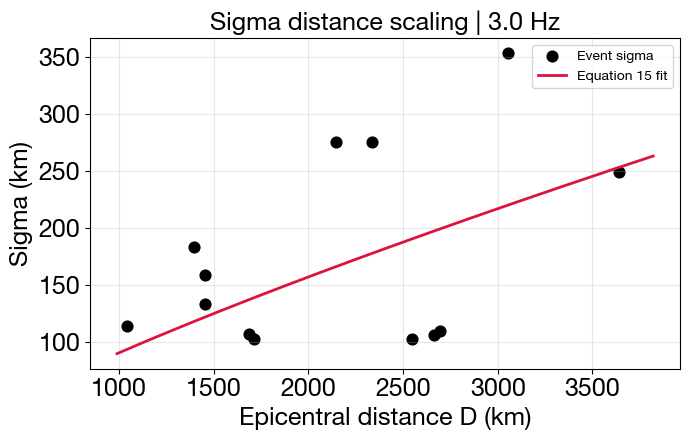

Saved band plot to: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/LSQ_Fitting/sigma_distance_by_band/sigma_distance_3.0Hz.png
Band 4.0 Hz: sigma0=185.137 km, beta=0.800 (fixed)
                                event station    epi_deg      epi_km  sigma_mean  sigma_pred
1976-03-06 10:03:00.015000+00:00__S15     S15  34.369254 1042.190937  108.411078  109.907152
1976-03-08 14:33:00.011000+00:00__S15     S15  47.933383 1453.500759  268.771192  143.416900
1975-11-10 07:46:00.004000+00:00__S16     S16  48.000000 1455.520820  104.204578  143.576333
1976-01-04 11:09:00.035000+00:00__S16     S16  55.664065 1687.920952  104.458110  161.640358
1976-03-06 10:03:00.009000+00:00__S14     S14  56.580047 1715.696605  105.424128  163.764783
1975-05-07 06:28:05.013000+00:00__S16     S16  64.000000 1940.694427  445.552851  180.731497
1972-12-06 22:59:00.008000+00:00__S14     S14  70.772241 2146.051452  484.675238  195.875548
1972-01-02 22:20:40.002000

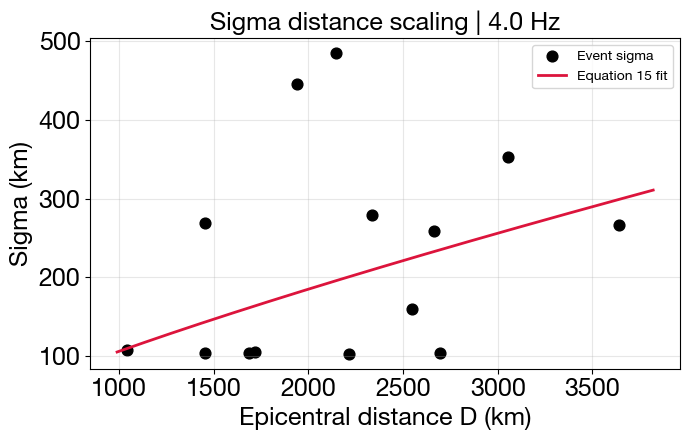

Saved band plot to: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/LSQ_Fitting/sigma_distance_by_band/sigma_distance_4.0Hz.png
Band 5.0 Hz: sigma0=177.431 km, beta=0.800 (fixed)
                                event station    epi_deg      epi_km  sigma_mean  sigma_pred
1976-03-06 10:03:00.015000+00:00__S15     S15  34.369254 1042.190937  137.396361  105.332513
1971-05-20 17:16:10.013000+00:00__S14     S14  46.000000 1394.874120  120.975995  132.994176
1976-03-08 14:33:00.011000+00:00__S15     S15  47.933383 1453.500759  124.794348  137.447492
1975-11-10 07:46:00.004000+00:00__S16     S16  48.000000 1455.520820  272.391519  137.600290
1976-01-04 11:09:00.035000+00:00__S16     S16  55.664065 1687.920952  124.165561  154.912440
1976-03-06 10:03:00.009000+00:00__S14     S14  56.580047 1715.696605  103.565833  156.948440
1975-05-07 06:28:05.013000+00:00__S16     S16  64.000000 1940.694427  462.803444  173.208953
1972-12-06 22:59:00.008000

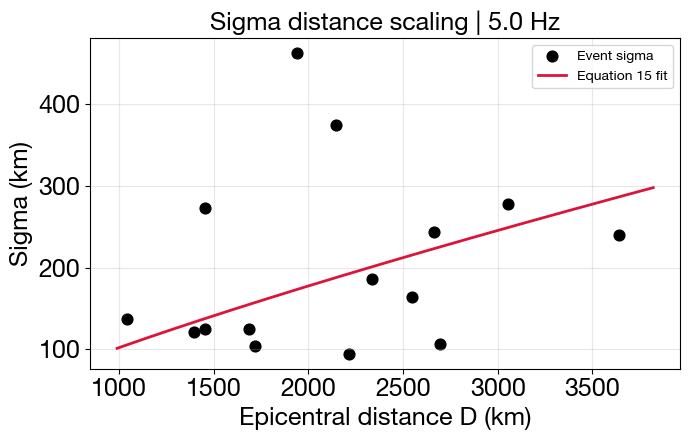

Saved band plot to: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/LSQ_Fitting/sigma_distance_by_band/sigma_distance_5.0Hz.png
Band 6.0 Hz: sigma0=152.206 km, beta=0.800 (fixed)
                                event station    epi_deg      epi_km  sigma_mean  sigma_pred
1976-03-06 10:03:00.015000+00:00__S15     S15  34.369254 1042.190937  123.050624   90.358019
1971-05-20 17:16:10.013000+00:00__S14     S14  46.000000 1394.874120  117.800028  114.087190
1976-03-08 14:33:00.011000+00:00__S15     S15  47.933383 1453.500759  130.725227  117.907405
1975-11-10 07:46:00.004000+00:00__S16     S16  48.000000 1455.520820  200.631871  118.038480
1976-01-04 11:09:00.035000+00:00__S16     S16  55.664065 1687.920952  239.242977  132.889465
1976-03-06 10:03:00.009000+00:00__S14     S14  56.580047 1715.696605  105.851375  134.636019
1972-12-06 22:59:00.008000+00:00__S14     S14  70.772241 2146.051452  116.787472  161.035258
1972-01-02 22:20:40.002000

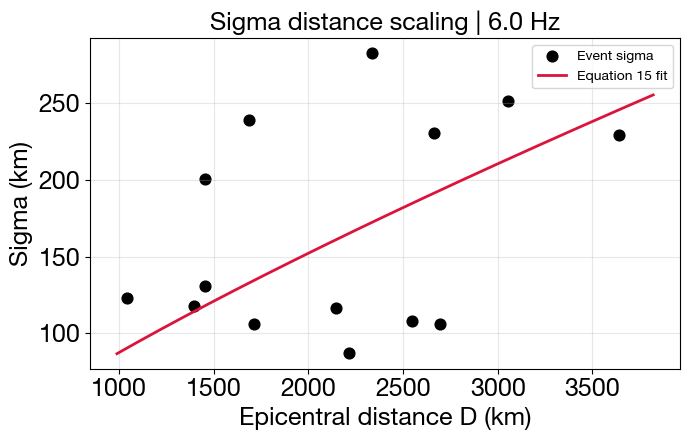

Saved band plot to: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/LSQ_Fitting/sigma_distance_by_band/sigma_distance_6.0Hz.png
Band 7.0 Hz: sigma0=209.741 km, beta=0.800 (fixed)
                                event station    epi_deg      epi_km  sigma_mean  sigma_pred
1976-03-06 10:03:00.015000+00:00__S15     S15  34.369254 1042.190937  106.571715  124.513632
1971-05-20 17:16:10.013000+00:00__S14     S14  46.000000 1394.874120  114.598810  157.212503
1976-03-08 14:33:00.011000+00:00__S15     S15  47.933383 1453.500759  311.900108  162.476771
1975-11-10 07:46:00.004000+00:00__S16     S16  48.000000 1455.520820  414.610107  162.657392
1976-01-04 11:09:00.035000+00:00__S16     S16  55.664065 1687.920952  133.325448  183.122096
1976-03-06 10:03:00.009000+00:00__S14     S14  56.580047 1715.696605  104.968876  185.528854
1975-05-07 06:28:05.013000+00:00__S16     S16  64.000000 1940.694427  492.669024  204.750417
1972-12-06 22:59:00.008000

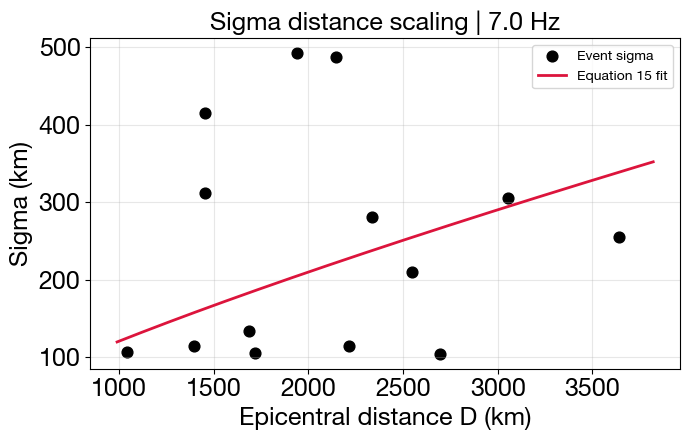

Saved band plot to: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/LSQ_Fitting/sigma_distance_by_band/sigma_distance_7.0Hz.png
Band 8.0 Hz: sigma0=157.465 km, beta=0.800 (fixed)
                                event station    epi_deg      epi_km  sigma_mean  sigma_pred
1976-03-06 10:03:00.015000+00:00__S15     S15  34.369254 1042.190937  101.656798   93.479641
1976-03-08 14:33:00.011000+00:00__S15     S15  47.933383 1453.500759  254.718908  121.980782
1975-11-10 07:46:00.004000+00:00__S16     S16  48.000000 1455.520820  158.270036  122.116385
1976-01-04 11:09:00.035000+00:00__S16     S16  55.664065 1687.920952  265.766716  137.480431
1976-03-06 10:03:00.009000+00:00__S14     S14  56.580047 1715.696605  104.210772  139.287324
1975-05-07 06:28:05.013000+00:00__S16     S16  64.000000 1940.694427  106.555320  153.718072
1972-12-06 22:59:00.008000+00:00__S14     S14  70.772241 2146.051452  223.251762  166.598584
1972-01-02 22:20:40.002000

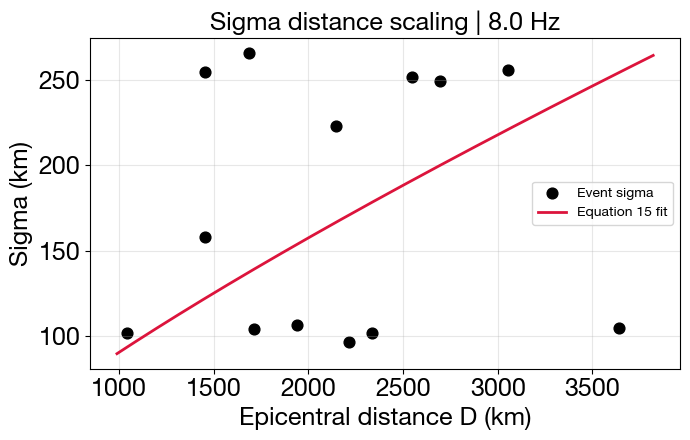

Saved band plot to: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/LSQ_Fitting/sigma_distance_by_band/sigma_distance_8.0Hz.png
Band 9.0 Hz: sigma0=157.293 km, beta=0.800 (fixed)
                                event station    epi_deg      epi_km  sigma_mean  sigma_pred
1976-03-06 10:03:00.015000+00:00__S15     S15  34.369254 1042.190937  174.725733   93.377845
1976-03-08 14:33:00.011000+00:00__S15     S15  47.933383 1453.500759  234.474371  121.847949
1975-11-10 07:46:00.004000+00:00__S16     S16  48.000000 1455.520820  247.707755  121.983404
1976-01-04 11:09:00.035000+00:00__S16     S16  55.664065 1687.920952  232.777021  137.330719
1976-03-06 10:03:00.009000+00:00__S14     S14  56.580047 1715.696605  106.290610  139.135645
1972-12-06 22:59:00.008000+00:00__S14     S14  70.772241 2146.051452  251.635939  166.417163
1972-01-02 22:20:40.002000+00:00__S15     S15  73.000000 2213.604581  103.803340  170.594901
1973-06-20 20:15:00.023000

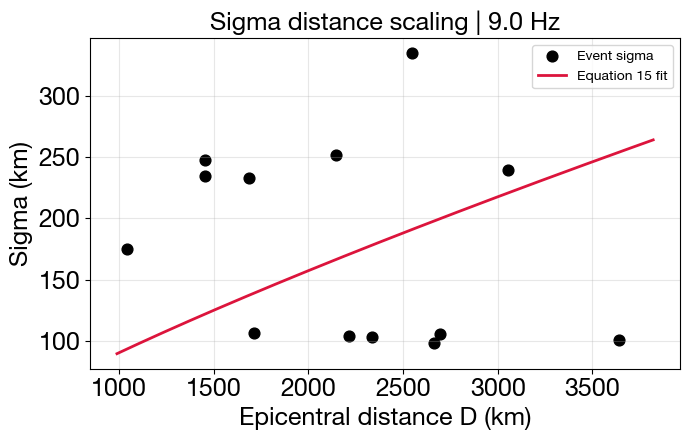

Saved band plot to: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/LSQ_Fitting/sigma_distance_by_band/sigma_distance_9.0Hz.png
Saved event-band sigma summary to: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/LSQ_Fitting/fit_envelopes_sigma_by_event_and_band.csv
Saved event sigma summary to: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/LSQ_Fitting/fit_envelopes_sigma_by_event.csv
Saved sigma distance plot to: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/LSQ_Fitting/fit_envelopes_sigma_distance_scaling.png

Failed fits:
                                event  fc_Hz             reason
1971-05-20 17:16:10.013000+00:00__S14    4.0 Missing t0_dt_mean
1971-05-20 17:16:10.013000+00:00__S14    8.0 Missing t0_dt_mean
1971-05-20 17:16:10.013000+00:00__S14    9.0 Missing t0_dt_mean
1975-05

In [54]:
summary_cols = [
    "event", "station", "epi_deg", "fc_Hz", "success", "fit_start", "fit_end",
    "cost", "ssr", "rmse", "log10_A2", "q0", "alpha", "sigma", "water_level"
]
print(results_all_events_df[summary_cols].to_string(index=False))

SIGMA_EVENT_BAND_CSV = os.path.join(RESULTS_DIR, "fit_envelopes_sigma_by_event_and_band.csv")
SIGMA_BAND_PLOT_DIR = os.path.join(RESULTS_DIR, "sigma_distance_by_band")
results_all_events_df = results_all_events_df.copy()
results_all_events_df["epi_km"] = MOON_RADIUS_KM * np.deg2rad(results_all_events_df["epi_deg"])
os.makedirs(SIGMA_BAND_PLOT_DIR, exist_ok=True)

print()
print("Sigma summary by event and frequency band:")
sigma_by_event_band = (
    results_all_events_df[["event", "station", "epi_deg", "epi_km", "fc_Hz", "sigma", "rmse", "q0", "alpha"]]
    .sort_values(["event", "fc_Hz"])
    .reset_index(drop=True)
)
sigma_by_event_band.to_csv(SIGMA_EVENT_BAND_CSV, index=False)
print(sigma_by_event_band.to_string(index=False))

print()
print("Sigma pivot table (rows=event, columns=frequency band):")
sigma_event_band_pivot = (
    sigma_by_event_band.pivot_table(index=["event", "station", "epi_deg"], columns="fc_Hz", values="sigma", aggfunc="first")
    .sort_index()
)
print(sigma_event_band_pivot.to_string())

print()
print("Fit results printed per frequency band:")
for fc_band in sorted(results_all_events_df["fc_Hz"].unique()):
    print()
    print(f"Band {fc_band:.1f} Hz")
    band_df = results_all_events_df.loc[results_all_events_df["fc_Hz"] == fc_band, summary_cols].sort_values("epi_deg")
    print(band_df.to_string(index=False))

print()
print("Sigma summary by frequency:")
sigma_by_band = (
    results_all_events_df.groupby("fc_Hz")["sigma"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
)
print(sigma_by_band.to_string(index=False))

MOON_RADIUS_KM = 1737.4
D0_KM = 2000.0
BETA_FIXED = 0.8
SIGMA_EVENT_CSV = os.path.join(RESULTS_DIR, "fit_envelopes_sigma_by_event.csv")
SIGMA_DISTANCE_PLOT = os.path.join(RESULTS_DIR, "fit_envelopes_sigma_distance_scaling.png")

print()
print("Sigma summary by event:")
sigma_by_event = (
    results_all_events_df.groupby(["event", "station", "epi_deg", "epi_km"])["sigma"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
    .rename(columns={"mean": "sigma_mean", "std": "sigma_std", "min": "sigma_min", "max": "sigma_max"})
    .sort_values("epi_deg")
)
sigma_by_event.to_csv(SIGMA_EVENT_CSV, index=False)
print(sigma_by_event.to_string(index=False))

valid = sigma_by_event[(sigma_by_event["epi_km"] > 0) & (sigma_by_event["sigma_mean"] > 0)].copy()
if len(valid) < 2:
    raise RuntimeError("Need at least two events with positive sigma_mean to fit equation 15.")

# Equation (15) from the paper, applied here to fitted sigma values:
# sigma(D) = sigma0 * (D / D0)^beta, with D0 = 100 km.
# beta is fixed and only sigma0 is estimated.
x = np.log(valid["epi_km"] / D0_KM)
y = np.log(valid["sigma_mean"])
log_sigma0 = np.mean(y - BETA_FIXED * x)
sigma0 = float(np.exp(log_sigma0))
valid["sigma_pred"] = sigma0 * (valid["epi_km"] / D0_KM) ** BETA_FIXED

print()
print(f"Equation 15 fit with D0 = {D0_KM:.1f} km:")
print(f"sigma(D) = {sigma0:.3f} * (D / {D0_KM:.1f} km)^{BETA_FIXED:.3f}")
print(f"Estimated sigma0 = {sigma0:.3f} km")
print(f"Fixed beta = {BETA_FIXED:.3f}")

d_plot = np.linspace(valid["epi_km"].min() * 0.95, valid["epi_km"].max() * 1.05, 200)
sigma_plot = sigma0 * (d_plot / D0_KM) ** BETA_FIXED

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(results_all_events_df["epi_km"], results_all_events_df["sigma"], alpha=0.35, label="Event-band fits")
ax.scatter(valid["epi_km"], valid["sigma_mean"], color="k", s=60, label="Event mean sigma")
ax.plot(d_plot, sigma_plot, color="crimson", lw=2, label="Equation 15 fit")
ax.set_xlabel("Epicentral distance D (km)")
ax.set_ylabel("Sigma (km)")
ax.set_title("Sigma distance scaling")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(SIGMA_DISTANCE_PLOT, dpi=200)
plt.show()

print()
print("Equation 15 fit per frequency band:")
for fc_band in sorted(results_all_events_df["fc_Hz"].unique()):
    band_event_df = (
        results_all_events_df.loc[results_all_events_df["fc_Hz"] == fc_band]
        .groupby(["event", "station", "epi_deg", "epi_km"], as_index=False)["sigma"]
        .mean()
        .rename(columns={"sigma": "sigma_mean"})
        .sort_values("epi_deg")
    )
    valid_band = band_event_df[(band_event_df["epi_km"] > 0) & (band_event_df["sigma_mean"] > 0)].copy()
    if len(valid_band) < 2:
        print(f"Band {fc_band:.1f} Hz: not enough events to fit equation 15.")
        continue

    x_band = np.log(valid_band["epi_km"] / D0_KM)
    y_band = np.log(valid_band["sigma_mean"])
    log_sigma0_band = np.mean(y_band - BETA_FIXED * x_band)
    sigma0_band = float(np.exp(log_sigma0_band))
    valid_band["sigma_pred"] = sigma0_band * (valid_band["epi_km"] / D0_KM) ** BETA_FIXED

    print(f"Band {fc_band:.1f} Hz: sigma0={sigma0_band:.3f} km, beta={BETA_FIXED:.3f} (fixed)")
    print(valid_band[["event", "station", "epi_deg", "epi_km", "sigma_mean", "sigma_pred"]].to_string(index=False))

    d_band = np.linspace(valid_band["epi_km"].min() * 0.95, valid_band["epi_km"].max() * 1.05, 200)
    sigma_band = sigma0_band * (d_band / D0_KM) ** BETA_FIXED
    fig_band, ax_band = plt.subplots(figsize=(7, 4.5))
    ax_band.scatter(valid_band["epi_km"], valid_band["sigma_mean"], color="k", s=60, label="Event sigma")
    ax_band.plot(d_band, sigma_band, color="crimson", lw=2, label="Equation 15 fit")
    ax_band.set_xlabel("Epicentral distance D (km)")
    ax_band.set_ylabel("Sigma (km)")
    ax_band.set_title(f"Sigma distance scaling | {fc_band:.1f} Hz")
    ax_band.grid(True, alpha=0.3)
    ax_band.legend()
    fig_band.tight_layout()
    band_plot_path = os.path.join(SIGMA_BAND_PLOT_DIR, f"sigma_distance_{fc_band:.1f}Hz.png")
    fig_band.savefig(band_plot_path, dpi=200)
    plt.show()
    print(f"Saved band plot to: {band_plot_path}")
print(f"Saved event-band sigma summary to: {SIGMA_EVENT_BAND_CSV}")
print(f"Saved event sigma summary to: {SIGMA_EVENT_CSV}")
print(f"Saved sigma distance plot to: {SIGMA_DISTANCE_PLOT}")

if not failed_fits_df.empty:
    print()
    print("Failed fits:")
    print(failed_fits_df.to_string(index=False))
